In [18]:
import polars as pl

# Load data from a CSV file
cast_df = pl.read_csv('cast.csv')

# Display the first few rows of the DataFrame
print("Initial Data:")
print(cast_df.head())

Initial Data:
shape: (5, 6)
┌──────────────────────┬──────┬──────────┬───────┬─────────────────────────┬──────┐
│ title                ┆ year ┆ name     ┆ type  ┆ character               ┆ n    │
│ ---                  ┆ ---  ┆ ---      ┆ ---   ┆ ---                     ┆ ---  │
│ str                  ┆ i64  ┆ str      ┆ str   ┆ str                     ┆ i64  │
╞══════════════════════╪══════╪══════════╪═══════╪═════════════════════════╪══════╡
│ Closet Monster       ┆ 2015 ┆ Buffy #1 ┆ actor ┆ Buffy 4                 ┆ 31   │
│ Suuri illusioni      ┆ 1985 ┆ Homo $   ┆ actor ┆ Guests                  ┆ 22   │
│ Battle of the Sexes  ┆ 2017 ┆ $hutter  ┆ actor ┆ Bobby Riggs Fan         ┆ 10   │
│ Secret in Their Eyes ┆ 2015 ┆ $hutter  ┆ actor ┆ 2002 Dodger Fan         ┆ null │
│ Steve Jobs           ┆ 2015 ┆ $hutter  ┆ actor ┆ 1988 Opera House Patron ┆ null │
└──────────────────────┴──────┴──────────┴───────┴─────────────────────────┴──────┘


In [12]:
# Filtering data: Select rows where the year is greater than 2000
filtered_df = cast_df.filter(pl.col('year') > 2000)

# Display the filtered data
print("\nFiltered Data (year > 2000):")
print(filtered_df)


Filtered Data (year > 2000):
shape: (1_656_397, 6)
┌────────────────────────┬──────┬────────────────┬─────────┬────────────────────────────┬──────┐
│ title                  ┆ year ┆ name           ┆ type    ┆ character                  ┆ n    │
│ ---                    ┆ ---  ┆ ---            ┆ ---     ┆ ---                        ┆ ---  │
│ str                    ┆ i64  ┆ str            ┆ str     ┆ str                        ┆ i64  │
╞════════════════════════╪══════╪════════════════╪═════════╪════════════════════════════╪══════╡
│ Closet Monster         ┆ 2015 ┆ Buffy #1       ┆ actor   ┆ Buffy 4                    ┆ 31   │
│ Battle of the Sexes    ┆ 2017 ┆ $hutter        ┆ actor   ┆ Bobby Riggs Fan            ┆ 10   │
│ Secret in Their Eyes   ┆ 2015 ┆ $hutter        ┆ actor   ┆ 2002 Dodger Fan            ┆ null │
│ Steve Jobs             ┆ 2015 ┆ $hutter        ┆ actor   ┆ 1988 Opera House Patron    ┆ null │
│ Straight Outta Compton ┆ 2015 ┆ $hutter        ┆ actor   ┆ Club Patron   

In [13]:
# Sorting data: Sort by year in descending order
sorted_df = filtered_df.sort('year')

# Display the sorted data
print("\nSorted Data (by year):")
print(sorted_df)




Sorted Data (by year):
shape: (1_656_397, 6)
┌───────────────────────────────────┬──────┬──────────────────┬─────────┬───────────────────┬──────┐
│ title                             ┆ year ┆ name             ┆ type    ┆ character         ┆ n    │
│ ---                               ┆ ---  ┆ ---              ┆ ---     ┆ ---               ┆ ---  │
│ str                               ┆ i64  ┆ str              ┆ str     ┆ str               ┆ i64  │
╞═══════════════════════════════════╪══════╪══════════════════╪═════════╪═══════════════════╪══════╡
│ De la calle                       ┆ 2001 ┆ Luis 'El Plojo'  ┆ actor   ┆ Froilán plaza del ┆ 80   │
│                                   ┆      ┆                  ┆         ┆ estudiante        ┆      │
│ Zoolander                         ┆ 2001 ┆ Angel 11:11      ┆ actor   ┆ Funky Loft Guest  ┆ 86   │
│ SpringBling Beach Towel Throwd…   ┆ 2001 ┆ A.J.             ┆ actor   ┆ Himself           ┆ null │
│ Olsen Banden Junior               ┆ 2001 ┆ 

In [14]:
select_columns_df = cast_df.select(["year", "title"])
print (select_columns_df)

sorted_columns_df = select_columns_df.sort('year')
sorted_columns_df.sort(by="year", descending=True ).head(10)

shape: (3_442_902, 2)
┌──────┬─────────────────────────────────┐
│ year ┆ title                           │
│ ---  ┆ ---                             │
│ i64  ┆ str                             │
╞══════╪═════════════════════════════════╡
│ 2015 ┆ Closet Monster                  │
│ 1985 ┆ Suuri illusioni                 │
│ 2017 ┆ Battle of the Sexes             │
│ 2015 ┆ Secret in Their Eyes            │
│ 2015 ┆ Steve Jobs                      │
│ …    ┆ …                               │
│ 1988 ┆ Foxtrot                         │
│ 2004 ┆ Niceland (Population. 1.000.00… │
│ 1985 ┆ Skammdegi                       │
│ 2003 ┆ U.S.S.S.S...                    │
│ 1999 ┆ Bye Bye Blue Bird               │
└──────┴─────────────────────────────────┘


year,title
i64,str
2115,"""100 Years"""
2115,"""100 Years"""
2115,"""100 Years"""
2025,"""Avatar 5"""
2025,"""Avatar 5"""
2025,"""Avatar 5"""
2025,"""Avatar 5"""
2025,"""Avatar 5"""
2025,"""Avatar 5"""


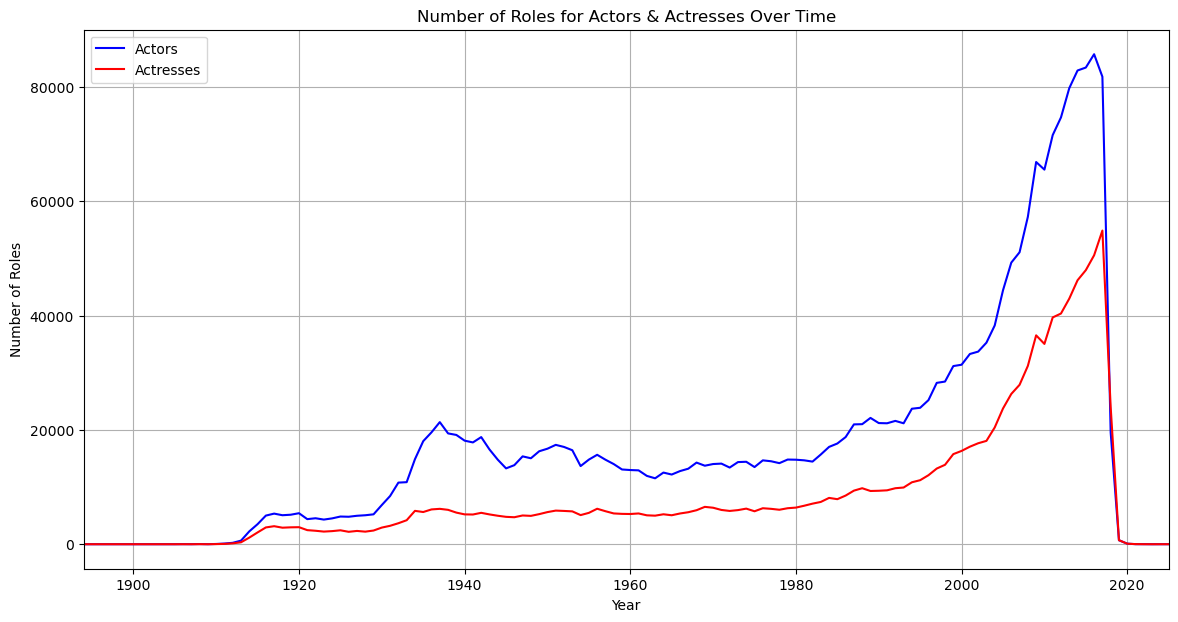

In [48]:
import polars as pl
import matplotlib.pyplot as plt

# Eager filtering, grouping, and aggregation
grouped_df = (
    cast_df
    .filter(pl.col("year") <= 2025)
    .group_by(["year", "type"])
    .agg(pl.len().alias("count"))
    .sort("year")
)

# Pivot using eager API
pivoted_df = (
    grouped_df
    .pivot(
        values="count",
        index="year",
        on="type"
    )
    .fill_null(0)
    .sort("year")
)

# Convert to pandas for plotting. matplotlib does not support Polars and hence the conversion to pandas
roles_by_year_pd = pivoted_df.to_pandas()

# Plot
plt.figure(figsize=(14, 7))
if 'actor' in roles_by_year_pd.columns:
    plt.plot(roles_by_year_pd['year'], roles_by_year_pd['actor'], label='Actors', color='blue')
if 'actress' in roles_by_year_pd.columns:
    plt.plot(roles_by_year_pd['year'], roles_by_year_pd['actress'], label='Actresses', color='red')

plt.title('Number of Roles for Actors & Actresses Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Roles')
plt.legend()
plt.grid(True)
plt.xlim(left=roles_by_year_pd['year'].min(), right=2025)
plt.show()

In [49]:
#Example of an Eager execution - the action happens immediately
a = 5
b = 10
c = a + b  # Addition happens immediately
print(c)    

15


In [55]:
# Conceptual lazy execution

operation1 = c  # Records an "add" operation
operation2 = c*20 # Records a "multiply" operation

result = operation2 # Only now are the actual calculations performed
print(result)

300


In [15]:
import pandas as pd

# Load data from a CSV file
pandas_cast_df = pd.read_csv('cast.csv')

#select a column in pandas,
pandas_cast_df["year"]
pandas_cast_df.loc[:,"year"]



0          2015
1          1985
2          2017
3          2015
4          2015
           ... 
3442897    1988
3442898    2004
3442899    1985
3442900    2003
3442901    1999
Name: year, Length: 3442902, dtype: int64

In [17]:
#Polars you would use the .select method:
cast_df.select("year")

year
i64
2015
1985
2017
2015
2015
…
1988
2004
1985
